# Building the 50K training set — the composition algorithm, explained

## What we are actually after

The Strategy Router must choose dense / hybrid / sparse retrieval for any
query a user types. A model learns only what its training data shows it,
so the 50,000 training queries must be two things at once:

- **Diverse** — every kind of query the router will meet shows up in
  learnable quantity: identifier-heavy telegrams ("CVE-2024-3094 xz
  backdoor"), long natural questions, math problems, negations, plain
  keyword lookups. A missing kind = a blind router in that region.
- **Representative** — the set should resemble real search traffic, not
  the quirks of whichever source corpus was biggest. Two failure modes:
  one dataset's writing style dominating a feature (the model learns the
  style, not the feature), and exotic queries crowding out the ordinary
  ones production actually sees.

Diversity can be engineered directly — that is what **targets** ("floors")
are: minimum amounts of each evidence kind. True representativeness cannot
be verified in-house — nobody holds the real traffic distribution — so the
pipeline does the honest version of it: keep large *unfiltered* samples of
ordinary queries (the no-preference and dark-forest slices), forbid any
single dataset from monopolizing a feature (the 50% rule), and defer the
final mix-check to evaluation time, when a real traffic log can weight
the scores.

## Assumptions — how we operationalize "diverse and representative"

We cannot verify a match to real search traffic in-house (nobody holds
that distribution), so we do not claim to. Instead we commit to a set of
explicit assumptions about what an honest, diverse selection should
satisfy — and the algorithm is the mechanical consequence of those
assumptions. If any one turns out wrong, we know exactly which pipeline
part to revisit.

1. **Diversity is measurable through the feature taxonomy.** The banks
   and scalar signals we profiled every query with span the axes the
   router needs to distinguish (identifier presence, sentence shape,
   length, structural depth). Covering them all with minimum amounts
   covers the router's decision space. → **Targets ("floors")**: one per
   feature kind, with a minimum evidence amount, not a proportion. If
   the taxonomy misses a real axis, the *dark forest* slice below is
   the hedge.

2. **A set built from four different kinds is more honest than any
   single kind alone.** No single sampling story survives contact with a
   real corpus; four together protect each other.
   - **Directed evidence** — queries chosen because they carry specific
     features, so the model has something to learn the mapping from
     (Slice A, 48% of the budget).
   - **A no-preference control** — an unbiased sample of the whole
     evidence population, so we can see what "natural" span-carrying
     queries look like without our own targeting bias (Slice B, 12%).
   - **Statistical strata** — queries with no features at all, spread
     across length / depth / shape bands so plain everyday questions
     are not crowded out by identifier-heavy ones (Slice C, 20%).
   - **A feature-blind reserve** — uniform draws from broad generalist
     sources, for what the taxonomy misses entirely (Slice D, 20%).
   → **The four slice classes and the 48 / 12 / 20 / 20 split.**

3. **No single dataset should dominate any feature's evidence.** If it
   does, the model risks learning that dataset's writing style as a
   proxy for the feature — diversity of evidence without diversity of
   source is fake diversity. → **The 50% anti-monopoly rule**, waived
   only where one dataset is genuinely the sole supplier.

4. **Not all evidence is equally trustworthy.** A rigid identifier is a
   fact; a look-alike guess is a hint. → **Evidence discounts**
   (1.0 / 0.75 / 0.5), so a target "filled" with guesses actually
   required more queries than one filled with rigid matches.

5. **The worst-covered kind is the binding metric.** For a router an
   under-covered feature is a blind spot in production; overfilling one
   target does not compensate for another sitting near empty. →
   **Maximin fill order**: always serve the least-covered target next
   (Act 2).

6. **Gradeable queries first; the rest carry a flag.** Only queries
   paired with relevance judgments can be labeled today; click-data
   queries need a separate judging step later. Both are needed — the
   assumption is that the labeling pipeline will grow, not that we drop
   the deferred rows. → **Two label lanes** (`qrels` first, then
   `deferred`).

7. **Failing to hit a target is information, not a bug.** If the
   catalog lacks enough queries to fill a target, that gap belongs on a
   purchase order for the query-generation stage — the pipeline never
   silently under-fills. → **The order sheet** with three reasons:
   supply exhausted, allowance capped, or budget ran out.

## The four design choices this notebook demonstrates

Everything above is *what we assume*. The four choices below are *how we
make each assumption executable*.

1. **Measure once, select cheaply.** Every query was profiled once into
   a feature catalog; selection re-runs in seconds without re-measuring.
2. **Selection is shopping.** A shopping list of evidence targets
   (assumption 1), a price tag on every query (assumption 4), a greedy
   shopper (assumption 5) — plus the anti-monopoly rule (assumption 3).
3. **Feed the hungriest target first; gradeable queries first.** Targets
   are absolute amounts (assumption 1), and the least-covered one is
   always served next (assumption 5); gradeable rows fill before
   deferred (assumption 6).
4. **The budget and the price list.** 50K split 48/12/20/20 across four
   slices (assumption 2); a rigid identifier pays 1.0 toward a target,
   a look-alike guess only 0.5 (assumption 4); unmet targets go to the
   order sheet (assumption 7).

Each act below makes one assumption observable — Act 1 the credit price
tags (assumption 1, 4), Act 2 the maximin loop (assumption 5), Act 3 the
anti-monopoly cap (assumption 3), Act 4 the discounts (assumption 4),
Act 5 the label lanes (assumption 6), Act 6 all seven at full scale.

```mermaid
flowchart LR
    CAT[("feature catalog<br/>225,752 profiled queries")] --> SM{"carries<br/>&ge;1 span?"}
    SM -- "yes: 32.2K evidence queries" --> B["Slice B (6K)<br/>no-preference: uniform sample,<br/>draws FIRST"]
    SM -- "no: 193.5K plain queries" --> C["Slice C (10K)<br/>14 scalar-band targets<br/>hungriest-first fill"]
    B --> APOOL["A pool = evidence queries minus B"]
    APOOL --> A["Slice A (24K)<br/>19 evidence targets<br/>hungriest-first fill"]
    CAT --> D["Slice D (10K)<br/>dark forest: blind draws from<br/>orcas / msmarco / legal-qa, &le;50% each"]
    A --> DEDUP["combine + deduplicate"]
    B --> DEDUP
    C --> DEDUP
    D --> DEDUP
    DEDUP --> INV["check invariants:<br/>sizes, lanes, caps, accounting"]
    INV --> TXT["attach query text<br/>from the dataset caches"]
    TXT --> SEL[("selection.parquet<br/>50,000 training queries")]
    A -. "unmet targets" .-> OS[("order sheet<br/>what to generate next")]
    C -. "unmet targets" .-> OS
```

> Mermaid diagrams render on GitHub and in VS Code; JupyterLab needs the
> mermaid extension.

| Term | Meaning |
| --- | --- |
| **target / floor** | one shopping-list line: "collect at least this much evidence of kind X" — an absolute amount, never a percentage |
| **credit** | what a selected query is worth to a target: rigid identifier banks 1.0, known-collision banks 0.75, look-alike guesses 0.5 |
| **allowance / cap** | no dataset may supply more than 50% of any target — the anti-monopoly rule (waived when only one dataset has the feature) |
| **label lane** | `qrels` = gradeable today; `deferred` = orcas click-data rows whose labels need a judging step later |
| **order sheet** | per-target unmet amounts + the reason — the shopping list handed to the query-generation stage |


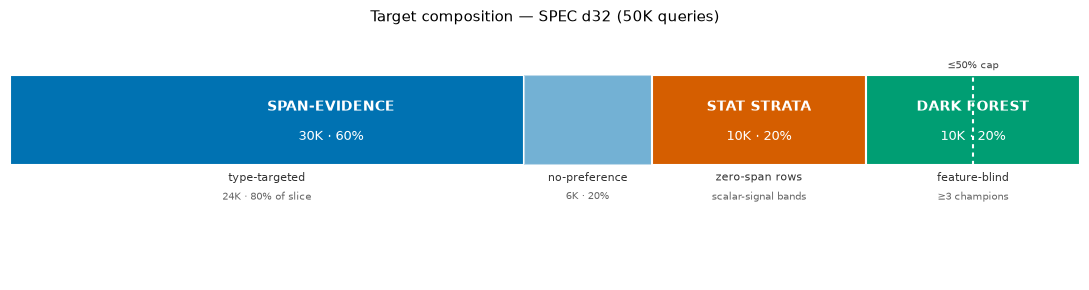

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from report_charts import target_composition

target_composition()
plt.show()

## Act 1 — a toy world

Twelve queries, three datasets (`web` is NOT gradeable — it plays orcas),
and three real feature banks so the real `SpanFloorDeriver` runs
unmodified:

- `ip_address` — a rigid network identifier (credit 1.0)
- `stock_ticker_like` — a look-alike guess bank (pools into
  `id:shape_guess`, credit 0.5)
- `negation` — a sentence marker (credit 1.0)

Targets are set to **3.0 weight** each so everything fits on one screen.
The supply is rigged to teach: only four `ticker_like` rows exist, worth
0.5 each — `id:shape_guess` can reach at most 2.0 of its 3.0 target, so a
real **shortfall** will appear.

In [ ]:
from composition.recipe import FloorRules, Recipe

toy_recipe = Recipe(floor_rules=FloorRules(span_floor_weight=3.0))

IP, TICKER, NEG = (
    "structured_identifiers.ip_address",
    "structured_identifiers.stock_ticker_like",
    "sentence_markers.negation",
)
toy = pd.DataFrame({
    "dataset":   ["papers"]*3 + ["code"]*4 + ["web"]*5,
    "query_id":  ["p1","p2","p3","c1","c2","c3","c4","w1","w2","w3","w4","w5"],
    "checkable": [True]*7 + [False]*5,
    IP:     [1,1,0, 1,0,0,1, 1,0,0,0,1],
    TICKER: [0,0,0, 0,1,1,1, 0,1,0,0,0],
    NEG:    [0,1,1, 0,0,1,0, 0,0,1,1,1],
})
toy

In [ ]:
from composition.floors import SpanFloorDeriver

toy_floors = SpanFloorDeriver(toy_recipe).derive(toy)

for floor in toy_floors:
    members = int((floor.credit > 0).sum())
    print(f"{floor.key:<16} wants={floor.amount}  supply={members} queries  "
          f"cap_waived={floor.cap_waived}")

# the targets x queries credit matrix — the derivers' entire output
# (.values strips pandas index alignment: credit is indexed by row
# position, not by query_id — we relabel columns after transposing)
matrix = pd.DataFrame(
    {f.key: f.credit.to_numpy() for f in toy_floors},
).T
matrix.columns = toy["query_id"].to_list()
fig, ax = plt.subplots(figsize=(8, 2.2))
ax.imshow(matrix.to_numpy(), cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(matrix.columns)), matrix.columns)
ax.set_yticks(range(len(matrix.index)), matrix.index)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix.iloc[i, j]
        if value:
            ax.text(j, i, f"{value:g}", ha="center", va="center", fontsize=8,
                    color="white" if value > 0.6 else "black")
ax.set_title("credit matrix: what each query is worth to each target")
plt.tight_layout(); plt.show()

# note the ticker_like rows: 0.5 apiece — a look-alike guess is worth half
# the evidence of a rigid identifier

## Act 2 — the loop: greedy + maximin

The loop makes **two decisions on every pick**, and understanding why we
need both is the whole point of this act:

- **Which target eats next?** — the *maximin* rule.
- **Which query feeds it?** — the *greedy* rule.

They solve two different failures.

### Why not just maximize the total collected evidence?

A concrete case. Two targets, each wanting **10 weight of evidence**.
**Budget = 30 queries.** The pool has:

- **20 queries carrying feature X** — a rigid identifier, worth **1.0**
  to target X each.
- **20 queries carrying feature Y** — a look-alike guess, worth **0.5**
  to target Y each.

A shopper that only cares about *total collected evidence* sorts the
pool by worth-per-query. The 20 rigid rows (worth 1.0) come first, then
10 guess rows (worth 0.5). Scorecard:

| shopper | X collected | Y collected | X ratio | Y ratio | total |
| --- | --- | --- | --- | --- | --- |
| total-maximizer | 20 | 5 | **200%** | **50%** | 25 |
| maximin | 10 | 10 | 100% | 100% | 20 |

The total-maximizer collected *more evidence in aggregate* (25 vs 20)
and yet **half of target Y is empty** — the router will meet Y-flavored
queries in production it has never trained on. Maximin collects less
total but hits both floors: it always serves whichever target has the
lowest fill/wants ratio, so the two ratios climb in lockstep. In this
example that means one rigid pick for every two guess picks
(1.0 credit vs 0.5 credit per row), and both floors close at pick 30.

For router training, **the worst-covered target is the binding metric**
— one empty target is a blind spot in production, and no amount of
overfilling elsewhere compensates.

### The picture to keep: water-filling

Every target is a glass; every pick pours one query into the *lowest*
glass. All glasses rise together, and if the budget stops early,
coverage is balanced instead of "first seven done, rest empty". A glass
that cannot rise further (supply gone, or every supplier at its
allowance) is set aside and *named* on the order sheet — a starved
target is a signal, not a silent casualty.

### Why greedy on top of maximin?

Maximin decides *which target* to serve, but many queries can feed it.
Some queries carry only that one feature; others carry several. A query
that credits target Y AND target Z at once advances two glasses in a
single pick. So within the chosen target, the shopper picks **greedily
by total marginal gain** — the candidate whose credit sums highest
across all still-open targets.

Two consequences:

1. **Fewer picks to close everything.** Multi-feature queries are
   preferred, so the same budget reaches further.
2. **Diminishing returns hold.** Once a target closes, queries that
   only credited *that* target become less attractive; the greedy
   choice naturally shifts. This is what gives the algorithm its
   robustness guarantee (formally: submodular greedy).

(Honest caveat: the *maximin* objective — the minimum of many coverage
scores — does not itself have the diminishing-returns property, so the
whole loop is a well-motivated heuristic without a numerical guarantee.
A fancier algorithm called SATURATE is the named fallback if a real
run ever visibly starves targets.)

```mermaid
flowchart TD
    START(["fill one lane"]) --> Q1{"budget left?"}
    Q1 -- "no" --> EXIT(["lane done"])
    Q1 -- "yes" --> Q2{"any target still open<br/>and not exhausted?"}
    Q2 -- "no" --> EXIT
    Q2 -- "yes" --> WEAK["hungriest = target with the<br/>lowest collected/wanted ratio"]
    WEAK --> CAND["candidates: carry evidence for it,<br/>in this lane, unselected,<br/>dataset under its 50% allowance"]
    CAND --> Q3{"candidates<br/>empty?"}
    Q3 -- "yes" --> EXH["mark hungriest exhausted<br/>(this lane only)"]
    EXH --> Q1
    Q3 -- "no" --> PICK["pick the candidate worth most<br/>across ALL open targets"]
    PICK --> BOOK["select it: budget -1,<br/>credit every target it feeds"]
    BOOK --> Q4{"a target closed or an<br/>allowance just filled up?"}
    Q4 -- "yes" --> REFRESH["refresh the worth scores"]
    REFRESH --> Q1
    Q4 -- "no" --> Q1
```

Distilled to pseudocode (the real thing is `composition/fill.py`):

```text
for lane in (gradeable, deferred):
    while budget > 0 and any target open in this lane:
        hungriest  = target with lowest collected/wanted    # maximin
        candidates = its members, in lane, unselected, under allowance
        if none: mark hungriest exhausted (this lane); continue
        pick       = candidate worth most across open targets  # greedy
        select pick: budget -1, credit EVERY target it feeds
top-up any leftover budget uniformly (gradeable first)
unmet targets -> order sheet (exhausted / capped / budget)
```

In [45]:
from composition.fill import FloorLedger, WeakestFirstFill


def replay(pool, floors, result, recipe, every=1):
    """Re-run the engine's pick order through a fresh ledger and
    snapshot the per-target ratios — trajectories from the REAL run."""
    codes, names = pd.factorize(pool["dataset"], sort=True)
    ledger = FloorLedger(floors, list(names), recipe.floor_rules.cap_frac)
    credit = np.column_stack(
        [f.credit.reindex(pool.index).to_numpy(float) for f in floors])
    keys = [f.key for f in floors]
    rows = []
    for i, (row, lane) in enumerate(zip(result.picked, result.lanes), 1):
        ledger.add(credit[row], codes[row], lane)
        if i % every == 0:
            rows.append({
                "pick": i,
                "query": pool.iloc[row]["query_id"],
                "dataset": pool.iloc[row]["dataset"],
                "lane": lane,
                **{k: round(r, 2) for k, r in zip(keys, ledger.ratios())},
            })
    return pd.DataFrame(rows).set_index("pick")


toy_engine = WeakestFirstFill(toy, toy_floors, toy_recipe, np.random.default_rng(0))
toy_result = toy_engine.run(8)
trace = replay(toy, toy_floors, toy_result, toy_recipe)
print("shortfalls:", [(s.key, s.reason, s.missing) for s in toy_result.shortfalls])
trace

shortfalls: [('id:shape_guess', 'exhausted', 1.0)]


,query,dataset,lane,id:network,id:shape_guess,marker:negation
pick,,,,,,
1,p2,papers,qrels,0.33,0.00,0.33
2,c3,code,qrels,0.33,0.17,0.67
3,c4,code,qrels,0.67,0.33,0.67
4,c2,code,qrels,0.67,0.50,0.67
5,p1,papers,qrels,1.00,0.50,0.67
6,p3,papers,qrels,1.00,0.50,1.00
7,w2,web,deferred,1.00,0.67,1.00
8,c1,code,qrels,1.33,0.67,1.00


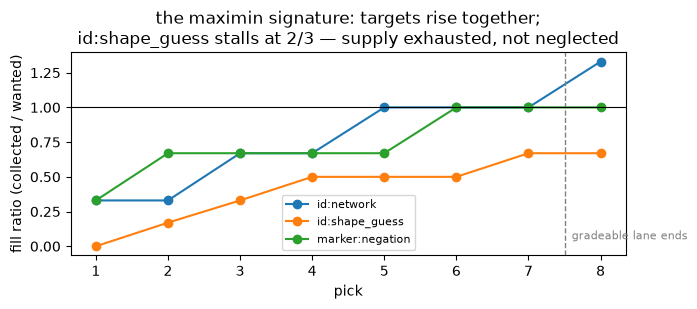

In [46]:
floor_keys = [f.key for f in toy_floors]
fig, ax = plt.subplots(figsize=(7, 3.2))
for key in floor_keys:
    ax.plot(trace.index, trace[key], marker="o", label=key)
qrels_picks = (trace["lane"] == "qrels").sum()
ax.axvline(qrels_picks + 0.5, color="gray", linestyle="--", linewidth=1)
ax.text(qrels_picks + 0.6, 0.05, "gradeable lane ends", fontsize=8, color="gray")
ax.axhline(1.0, color="black", linewidth=0.8)
ax.set_xlabel("pick"); ax.set_ylabel("fill ratio (collected / wanted)")
ax.set_title("the maximin signature: targets rise together;\n"
             "id:shape_guess stalls at 2/3 — supply exhausted, not neglected")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Act 3 — the anti-monopoly rule

Why it exists: if one dataset supplies a whole target, the router can
learn that dataset's *writing style* as a stand-in for the feature —
diversity of evidence without diversity of source is fake diversity. So
no dataset may supply more than 50% of any target. When the rule bites
while supply remains, the order sheet says `capped`: "more rows exist,
but buying them would buy a monoculture." Exactly this happened to
`id:network` in the real build — orcas delivered its allowance, nobody
else had supply, and the remaining 434 weight went to the order sheet
for the generation stage.

Toy demonstration: give `bigcorp` overwhelming supply and watch the rule
stop it.

In [47]:
cap_toy = pd.DataFrame({
    "dataset":   ["bigcorp"]*6 + ["indie"]*1,
    "query_id":  [f"b{i}" for i in range(6)] + ["i1"],
    "checkable": [True]*7,
    IP:  [1]*7,
})
cap_floors = SpanFloorDeriver(toy_recipe).derive(cap_toy)   # one target: id:network, wants 3.0
cap_engine = WeakestFirstFill(cap_toy, cap_floors, toy_recipe, np.random.default_rng(0))
cap_result = cap_engine.run(7)

ledger = cap_result.ledger
share = pd.Series(ledger.by_dataset[0], index=ledger.datasets)
print("target wants:", ledger.amounts[0], "| allowance per dataset:",
      toy_recipe.floor_rules.cap_frac * ledger.amounts[0])
print("credit by dataset:\n", share.to_string())
print("shortfalls:", [(s.key, s.reason, s.missing) for s in cap_result.shortfalls])

target wants: 3.0 | allowance per dataset: 1.5
credit by dataset:
 bigcorp    2.0
indie      1.0
shortfalls: []


## Act 4 — evidence currency: guesses are worth less

A target's amount is an **evidence** amount, not a row count. A query
pays in at the rate of its most trustworthy matching bank:

| supply | rows needed for a 1,000-weight target |
| --- | --- |
| rigid identifiers (CVE, IP, UUID...) | 1,000 |
| known-collision formats | 1,334 |
| look-alike guesses (`*_like`) | 2,000 |

The logic: a bare caps-and-digits token that merely *looks* like a ticker
might be a gene symbol — it is evidence that *something* identifier-shaped
is present, but weaker evidence. The accounting itself encodes the
distrust: a target "filled" with guesses required twice the rows.
Targets are deliberately sized below the row budget (19 × 1,000 weight
under 24,000 rows) so this inflation can never make the arithmetic
impossible — an order-sheet line always means the *supply* ran out,
never the math.

## Act 5 — two label lanes

```mermaid
flowchart LR
    P["slice pool"] --> L1["lane 1: gradeable today<br/>(datasets with relevance judgments)"]
    L1 --> L2["lane 2: deferred<br/>(orcas click data — labels come later)"]
    L2 --> T1["top-up: uniform, gradeable first"]
    T1 --> T2["top-up: uniform, deferred"]
    T2 --> S["unmet targets go to the order sheet<br/>with a reason: exhausted / capped / budget"]
```

The entire gradeable tier fills before any deferred row enters — visible
in the toy trace (`web` rows only appear after the dashed line) and at
full scale (the first 15,677 picks of slice A are all gradeable). The
lane is recorded per row as `label_lane`, so the labeling stage can
start on the gradeable rows today while the deferred lane waits for the
click-based / LLM-as-judge path.

## Act 6 — full scale

Everything above, now over the real catalog. First the artifact on disk,
then a live re-run of slice A to watch the trajectories.

In [48]:
selection = pd.read_parquet("data/composition/selection.parquet")
order_sheet = pd.read_parquet("data/composition/order_sheet.parquet")

print(len(selection), "rows")
display(pd.crosstab(selection["slice"], selection["label_lane"]))
display(pd.crosstab(selection["dataset"], selection["slice"]))
order_sheet

50000 rows


label_lane,deferred,qrels
slice,,
A,8323,15677
B,2351,3649
C,70,9930
D,5000,5000


slice,A,B,C,D
dataset,,,,
beir-nfcorpus,28,8,287,0
bright-aops,88,23,0,0
bright-leetcode,110,32,0,0
bright-theoremqa-questions,139,37,18,0
crumb-clinical-trial,91,22,0,0
crumb-code-retrieval,2885,675,105,0
crumb-legal-qa,290,60,1200,2000
crumb-paper-retrieval,46,14,12,0
crumb-set-operation-entity-retrieval,180,36,207,0


,slice,floor,amount,credit,missing,reason
0,A,id:datetime,1000.0,3.00,997.00,exhausted
1,A,id:logistics,1000.0,109.50,890.50,exhausted
2,A,id:media,1000.0,124.25,875.75,exhausted
3,A,id:medical,1000.0,7.50,992.50,exhausted
4,A,id:network,1000.0,566.25,433.75,capped
5,A,id:shape_guess,1000.0,864.25,135.75,exhausted
6,A,logical:operator_syntax,1000.0,35.00,965.00,exhausted
7,A,marker:greeting,1000.0,139.00,861.00,exhausted
8,A,marker:interjection,1000.0,147.00,853.00,exhausted
9,A,marker:politeness,1000.0,986.00,14.00,exhausted


In [49]:
# live re-run of slice A (~1 minute): reproduces the build exactly —
# same seed, same order (the no-preference slice draws first, then A
# fills targets from the remainder)
from composition.floors import span_mask

catalog = (pd.read_parquet("data/feature_table/catalog.parquet")
           .sort_values(["dataset", "query_id"], kind="stable")
           .reset_index(drop=True))
recipe = Recipe()
rng = np.random.default_rng(recipe.seed)
span_pool = catalog[span_mask(catalog)]
floors = SpanFloorDeriver(recipe).derive(span_pool)
b_rows = span_pool.sample(n=recipe.no_preference_rows, random_state=rng)
a_pool = span_pool.loc[~span_pool.index.isin(b_rows.index)]

engine = WeakestFirstFill(a_pool, floors, recipe, rng)
result = engine.run(recipe.span_target_rows)
print("picks:", len(result.picked),
      "| gradeable:", result.lanes.count("qrels"),
      "| shortfalls:", len(result.shortfalls))

picks: 24000 | gradeable: 15677 | shortfalls: 10


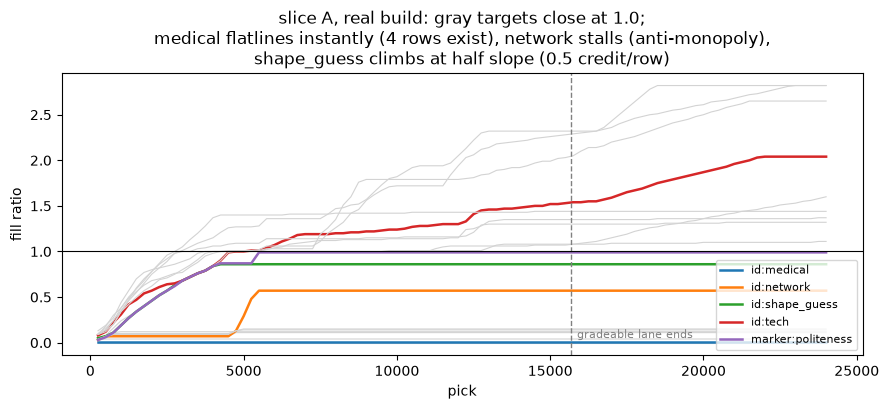

In [50]:
trajectory = replay(a_pool, floors, result, recipe, every=250)
highlight = ["id:network", "id:medical", "id:tech", "id:shape_guess",
             "marker:politeness"]
fig, ax = plt.subplots(figsize=(9, 4.2))
for key in [f.key for f in floors]:
    if key in highlight:
        ax.plot(trajectory.index, trajectory[key], label=key, linewidth=1.8)
    else:
        ax.plot(trajectory.index, trajectory[key], color="lightgray",
                linewidth=0.8)
qrels_picks = result.lanes.count("qrels")
ax.axvline(qrels_picks, color="gray", linestyle="--", linewidth=1)
ax.text(qrels_picks + 200, 0.05, "gradeable lane ends", fontsize=8, color="gray")
ax.axhline(1.0, color="black", linewidth=0.8)
ax.set_xlabel("pick"); ax.set_ylabel("fill ratio")
ax.set_title("slice A, real build: gray targets close at 1.0;\n"
             "medical flatlines instantly (4 rows exist), network stalls "
             "(anti-monopoly),\nshape_guess climbs at half slope (0.5 credit/row)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

## The class map, and where to go from here

```mermaid
classDiagram
    Recipe *-- SliceShares : shares
    Recipe *-- FloorRules : floor_rules
    SpanFloorDeriver ..> FloorSpec : derives 19
    StatFloorDeriver ..> FloorSpec : derives 14
    SpanFloorDeriver --> FloorRules : discounts
    WeakestFirstFill --> FloorSpec : consumes
    WeakestFirstFill *-- FloorLedger : books credit
    WeakestFirstFill ..> FillResult : returns
    FillResult *-- Shortfall : order-sheet lines
    SpanTargetSlice --> WeakestFirstFill : slice A
    StatStrataSlice --> WeakestFirstFill : slice C
    TargetComposition --> NoPreferenceSlice : B first
    TargetComposition --> SpanTargetSlice : then A
    TargetComposition --> StatStrataSlice : then C
    TargetComposition --> DarkForestSlice : then D
```

- **Change the recipe** — everything is `Recipe` (`composition/recipe.py`):
  `Recipe(total_rows=10_000)` scales the whole split; shares, floor rules
  and champions are nested models with their own validators.
- **Re-run** — `poetry run python scripts/compose_target.py --force`
  (deterministic: same catalog + recipe = byte-identical artifact).
- **Read the result** — `data/composition/summary.md` carries the
  per-target fill and lane tables; the order sheet is the generation
  stage's purchase order.
- **Escalations** (designed, not yet needed): SATURATE if the hungriest-
  first heuristic ever starves targets unfairly; integer programming if
  targets stay unfilled despite available supply — the `capped`
  shortfall reason is that trigger's detector.
- **One known shortcut**: the "worth" score skips a tiny correction near
  a target's closing moment (bounded by one row's credit against
  1,000-weight targets) — it buys event-driven score updates instead of
  24,000 full recomputes; see the `fill.py` docstring.